# 04 — Results: Qini Curves and the Full Comparison

This notebook brings everything together: the production-relevant metric
(Qini/AUUC, computed from observed data only) alongside the research metric
(PEHE, only possible because we have ground truth), across all four models
built across this project.

In [1]:
import sys
sys.path.append("../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib

from evaluation import qini_curve, auuc, pehe
from model import AttentionDragonNet, FeatureScaler, predict_cate

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

test_df = pd.read_parquet("../data/test_set.parquet")
feature_cols = ["loyalty_tier", "price_sensitivity", "lead_time_days",
                 "past_bookings", "device_mobile", "length_of_stay", "base_price"]

with open("../data/pehe_results.json") as f:
    pehe_results = pd.DataFrame(json.load(f))
pehe_results

,model,pehe
0,S-learner (naive),12.620476
1,T-learner (naive),11.517443
2,T-learner + IPW,11.398082
3,Attention-DragonNet,10.761373


In [2]:
# Load all four fitted models
s_model = joblib.load("../models/s_learner.joblib")
t_model_1 = joblib.load("../models/t_learner_treated.joblib")
t_model_0 = joblib.load("../models/t_learner_control.joblib")
ipw_model_1 = joblib.load("../models/ipw_t_learner_treated.joblib")
ipw_model_0 = joblib.load("../models/ipw_t_learner_control.joblib")

with open("../models/scaler.json") as f:
    scaler = FeatureScaler.from_dict(json.load(f))
dragonnet = AttentionDragonNet(d_model=32, n_heads=4, n_layers=2)
dragonnet.load_state_dict(torch.load("../models/attention_dragonnet.pt"))
dragonnet.eval()

# Predicted CATE from each model on the test set
s_features = feature_cols + ["treatment"]
test_treated = test_df[s_features].copy(); test_treated["treatment"] = 1
test_control = test_df[s_features].copy(); test_control["treatment"] = 0
s_pred = s_model.predict(test_treated) - s_model.predict(test_control)

t_pred = t_model_1.predict(test_df[feature_cols]) - t_model_0.predict(test_df[feature_cols])
ipw_pred = ipw_model_1.predict(test_df[feature_cols]) - ipw_model_0.predict(test_df[feature_cols])
dragonnet_pred = predict_cate(dragonnet, test_df, scaler)

predictions = {
    "S-learner (naive)": s_pred,
    "T-learner (naive)": t_pred,
    "T-learner + IPW": ipw_pred,
    "Attention-DragonNet": dragonnet_pred,
}

## Qini curves

Unlike PEHE, this uses **only observed outcomes and treatment assignment**
-- exactly what would be available after a real deployment, with no ground
truth required. Each curve ranks the test set by that model's predicted
uplift and traces the cumulative incremental gain from targeting the
top-k%. The diagonal is the random-targeting baseline; further above it is
better.

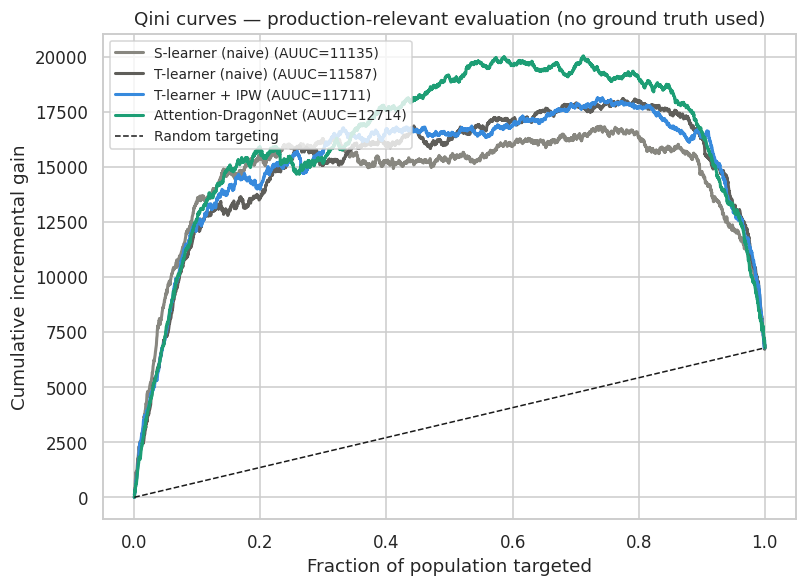

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = {"S-learner (naive)": "#888780", "T-learner (naive)": "#5F5E5A",
          "T-learner + IPW": "#378ADD", "Attention-DragonNet": "#1D9E75"}

auuc_scores = {}
for name, pred in predictions.items():
    qdf = qini_curve(test_df["y"].values, test_df["treatment"].values, pred)
    auuc_scores[name] = auuc(qdf)
    ax.plot(qdf["frac"], qdf["qini"], label=f"{name} (AUUC={auuc_scores[name]:.0f})",
            color=colors[name], linewidth=2)

ax.plot(qdf["frac"], qdf["random_qini"], "k--", linewidth=1, label="Random targeting")
ax.set_xlabel("Fraction of population targeted")
ax.set_ylabel("Cumulative incremental gain")
ax.set_title("Qini curves — production-relevant evaluation (no ground truth used)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/07_qini_curves.png", bbox_inches="tight")
plt.show()

## The headline comparison: PEHE and AUUC side by side

In [4]:
pehe_results["auuc"] = pehe_results["model"].map(auuc_scores)
pehe_results["pehe_improvement_vs_naive_s"] = (
    (pehe_results["pehe"].iloc[0] - pehe_results["pehe"]) / pehe_results["pehe"].iloc[0] * 100
)
pehe_results

,model,pehe,auuc,pehe_improvement_vs_naive_s
0,S-learner (naive),12.620476,11134.597129,0.000000
1,T-learner (naive),11.517443,11587.014517,8.740021
2,T-learner + IPW,11.398082,11710.987361,9.685800
3,Attention-DragonNet,10.761373,12714.454010,14.730844


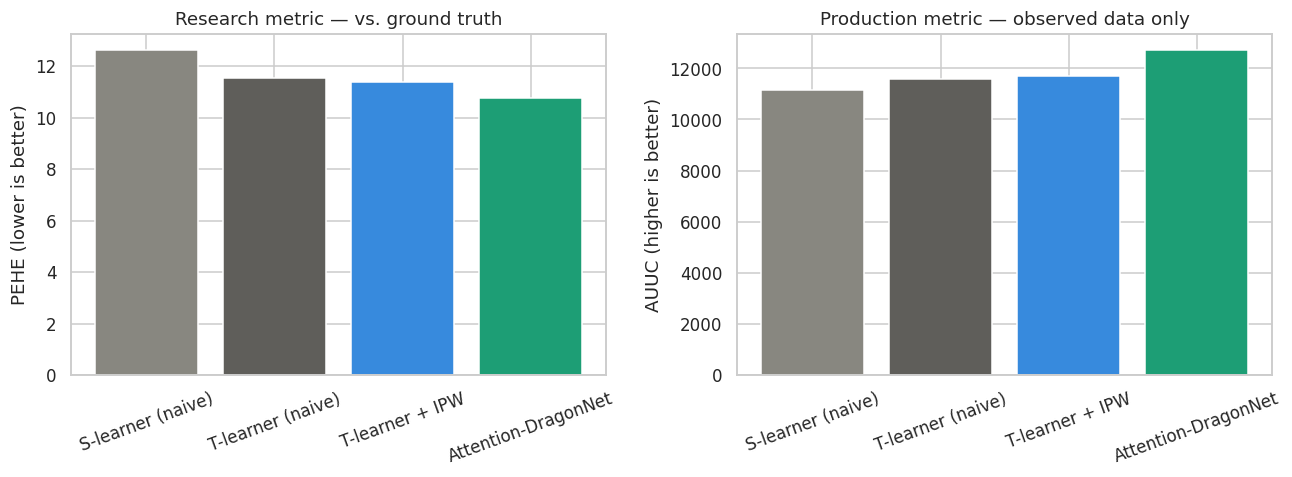

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
model_colors = [colors[m] for m in pehe_results["model"]]

axes[0].bar(pehe_results["model"], pehe_results["pehe"], color=model_colors)
axes[0].set_ylabel("PEHE (lower is better)")
axes[0].set_title("Research metric — vs. ground truth")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(pehe_results["model"], pehe_results["auuc"], color=model_colors)
axes[1].set_ylabel("AUUC (higher is better)")
axes[1].set_title("Production metric — observed data only")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../figures/08_headline_comparison.png", bbox_inches="tight")
plt.show()

**Both metrics agree** on the ranking (naive S < naive T < IPW-corrected T <
attention-DragonNet), which is itself a useful check: PEHE could only be
computed because we control the simulation, but AUUC is the metric that
would actually be available after a real deployment -- and it tells the
same story. That agreement is the strongest evidence that debiasing +
attention genuinely improved targeting quality, not just a metric we can
only check in a lab setting.

One honest caveat worth stating plainly: the targeted-regularization
epsilon in the DragonNet converged very close to zero during training,
meaning the doubly-robust *correction term* itself contributed only a
small increment here -- most of the DragonNet's improvement over the IPW
T-learner likely comes from the shared attention representation learning
feature interactions better, not from the targeted regularization
mechanism doing heavy lifting. That's a legitimate, explainable result
(the base outcome heads already fit the residual well) and worth having
ready as an answer if asked directly, rather than overselling the doubly
robust piece.

In [6]:
pehe_results.to_json("../data/final_results.json", orient="records", indent=2)
print("saved final_results.json")

saved final_results.json


In [7]:
# Export downsampled Qini curve series for the HTML frontend (no charting
# library dependency needed client-side -- just plain JSON arrays).
qini_export = {}
for name, pred in predictions.items():
    qdf = qini_curve(test_df["y"].values, test_df["treatment"].values, pred)
    idx = np.linspace(0, len(qdf) - 1, 150).astype(int)
    qini_export[name] = {
        "frac": qdf["frac"].values[idx].round(4).tolist(),
        "qini": qdf["qini"].values[idx].round(2).tolist(),
    }
idx = np.linspace(0, len(qdf) - 1, 150).astype(int)
qini_export["Random targeting"] = {
    "frac": qdf["frac"].values[idx].round(4).tolist(),
    "qini": qdf["random_qini"].values[idx].round(2).tolist(),
}
with open("../data/qini_curves.json", "w") as f:
    json.dump(qini_export, f, indent=2)
print("saved qini_curves.json")

saved qini_curves.json
